# Project 2: Joint Detection of AI-Generated Images and Post-Processing Alterations
#
Notebook structure: Imports, Globals, Utils, Data, Network, Train, Evaluation.
All reusable helper functions live in Utils. Network only defines the models, Train only runs
the training, and Evaluation only scores the trained models.

## Imports

### Install the packages [setup]
Most libraries are already on Kaggle, but we make sure transformers and peft are installed.

In [1]:
# %pip install -q numpy pandas matplotlib seaborn scikit-learn Pillow torch transformers peft

### Import everything we use [setup]
We bring in all the libraries once at the top so the rest of the notebook can use them.

In [2]:
# standard library
import os
import re
import copy
import random
from pathlib import Path

# data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
Image.MAX_IMAGE_PIXELS = None   # allow very large images
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from transformers import AutoModel, AutoImageProcessor
from huggingface_hub import login
from peft import LoraConfig, get_peft_model

## Globals

### All the settings in one place [config]
Every value we might want to change lives here, so we never have to hunt for it later.

In [3]:
# Reproducibility.
SEED = 42

# Dataset path.
if Path("/kaggle/input").exists():
    DATA_ROOT = "/kaggle/input/datasets/jannip/rrdataset/RRDataset_final"
else:
    DATA_ROOT = "./data/RRDataset_final"

# Folder names to labels.
# Task A (authenticity): is the image real or AI-generated?
REALFAKE_ID   = {"real": 0, "ai": 1}     # the number the model will predict
REALFAKE_NAME = {0: "real", 1: "fake"}   # a readable name for plots and tables

# Task B (transformation): what post-processing was applied?
TRANSFORM_FOLDERS = ["original", "transfer", "redigital"]   # the folder names on disk
TRANSFORM_ID      = {"original": 0, "transfer": 1, "redigital": 2}
TRANSFORM_NAME    = {"original": "original", "transfer": "transmitted", "redigital": "redigitized"}

CLASS_FOLDERS = ["real", "ai"]
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

# How much data to use, and how to split it.
SUBSET_PER_CLASS = 8000              # scenes per class to keep (each scene = 3 images)
SPLIT_RATIOS = (0.70, 0.15, 0.15)    # train / validation / test, measured in scenes

# Where to save outputs.
OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
INDEX_CSV = OUT_DIR / "rrdataset_index.csv"

# Backbone.
BACKBONE_ID = "facebook/dinov3-vitb16-pretrain-lvd1689m"   # DINOv3 (gated)
FEATURE_DIM = 768
FEATS_NPY   = OUT_DIR / "feats.npy"

# HuggingFace token for the gated DINOv3 download.
# Empty for Kaggle (use Add-ons -> Secrets), filled in for local runs.
HF_TOKEN = ""

# Head and training settings.
HIDDEN_DIM = 256
DROPOUT    = 0.3
EPOCHS     = 50
PATIENCE   = 8          # early stopping: stop if val does not improve for this many epochs
LR         = 1e-3
BATCH_SIZE = 256

# LoRA settings (Phase 3): instead of freezing the backbone, we let it adapt a little.
LORA_R      = 8
LORA_ALPHA  = 16
LORA_EPOCHS = 3
LORA_LR     = 1e-4
LORA_BATCH  = 64        # mixed precision frees memory, so we can use a bigger batch
LORA_WEIGHTS = OUT_DIR / "lora_model.pt"   # cache the trained LoRA so we do not retrain each time
RETRAIN_LORA = False   # set False once you're happy with the cached weights

## Utils
All the support functions and small helper classes used by the rest of the notebook.

### Make the run repeatable [reproducibility]
We fix every random seed so two runs give the same numbers and our results are trustworthy.

In [4]:
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

### Pick the device [hardware]
We use the GPU if there is one, otherwise the CPU. Training on the GPU is much faster.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)

Using device: cuda
GPU: Tesla T4 | CUDA 12.8


### Read the labels from a file name [data labels]
The three versions of one scene share a name apart from a prefix. Stripping the prefix gives one
id that links them, so later we can keep all three versions of a scene in the same split.

In [6]:
def get_base_id(filename):
    """Turn a file name into a scene id shared by its 3 transform versions.

        Culture_&_Religion_000001.png            -> Culture_&_Religion_000001
        transfer_Culture_&_Religion_000001.jpg   -> Culture_&_Religion_000001
        redigital_real_000001.jpg                -> real_000001
    """
    name_without_extension = os.path.splitext(filename)[0]
    return re.sub(r"^(transfer_|redigital_)", "", name_without_extension)


def get_scenario(base_id, is_fake):
    """AI file names start with a scenario (e.g. 'War_&_Conflict_Scenes_000012').
    Real images are just 'real_000012', so we label them all 'real'."""
    if not is_fake:
        return "real"
    return re.sub(r"_\d+$", "", base_id)   # drop the trailing number

### Bar chart of category counts [plotting]
A small helper that draws a labelled bar chart. We use it to check the class balance.

In [7]:
def bar_counts(values, title, ax):
    counts = values.value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("number of images")
    for i, n in enumerate(counts.values):
        ax.text(i, n, str(n), ha="center", va="bottom", fontsize=9)

### Dataset that reads one image [DINOv3 feature caching]
Opens an image and turns it into the tensor the backbone expects. The DataLoader uses many of
these in parallel, so reading the big images does not slow the GPU down.

In [8]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        image = Image.open(self.paths[i]).convert("RGB")
        return processor(images=image, return_tensors="pt").pixel_values[0]

### Run the backbone over many images [DINOv3]
Sends batches of images through the frozen backbone and keeps the CLS vector of each one. We
call this once and save the result, so every later experiment can reuse the saved numbers.

In [9]:
@torch.no_grad()
def extract_features(paths, batch_size=64, num_workers=4):
    # shuffle=False keeps the output rows in the same order as `paths` (and the table).
    loader = DataLoader(ImageDataset(paths), batch_size=batch_size,
                        num_workers=num_workers, pin_memory=True)
    all_feats, done = [], 0
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        cls = backbone(pixel_values=batch).last_hidden_state[:, 0]   # CLS token, one row per image
        all_feats.append(cls.cpu())
        done += len(batch)
        print(f"  {done} / {len(paths)} images", end="\r")
    return torch.cat(all_feats).numpy()

### Dataset that also returns the labels [LoRA]
Like the one above, but it also gives back the two labels. The LoRA model trains on images, so
it needs the answers during training, not only the pixels.

In [10]:
class LabeledImageDataset(torch.utils.data.Dataset):
    def __init__(self, frame):
        self.paths = frame["path"].tolist()
        self.ya = frame["realfake"].tolist()
        self.yb = frame["transform"].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        image = Image.open(self.paths[i]).convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt").pixel_values[0]
        return pixel_values, self.ya[i], self.yb[i]

### Accuracy of a single-task head [baseline]
Given a head and some features, returns the fraction of correct predictions. We use it during
training to watch the validation score.

In [11]:
def accuracy(head, X, y):
    head.eval()
    with torch.no_grad():
        preds = head(X.to(device)).argmax(1).cpu()
    return (preds == y).float().mean().item()

### Accuracy of the joint model [joint model]
The joint model returns two outputs at once, so this returns the accuracy of both tasks together.

In [12]:
def joint_accuracy(model, mask):
    model.eval()
    with torch.no_grad():
        out_a, out_b = model(features_tensor[mask].to(device))
    acc_a = (out_a.argmax(1).cpu() == labels_realfake[mask]).float().mean().item()
    acc_b = (out_b.argmax(1).cpu() == labels_transform[mask]).float().mean().item()
    return acc_a, acc_b

### Predictions of the joint model [joint model]
Returns the predicted class of each task. We use it to draw the joint model confusion matrices.

In [13]:
def joint_predict(model, mask):
    model.eval()
    with torch.no_grad():
        out_a, out_b = model(features_tensor[mask].to(device))
    return out_a.argmax(1).cpu(), out_b.argmax(1).cpu()

### Predictions of an image model [LoRA]
Runs an image-based model (the LoRA one) over a set of rows and returns the predicted classes
of both tasks. Mixed precision keeps the backbone pass fast.

In [14]:
@torch.no_grad()
def predict_images(model, frame, batch_size=LORA_BATCH):
    model.eval()
    use_amp = (device.type == "cuda")
    loader = DataLoader(LabeledImageDataset(frame), batch_size=batch_size,
                        num_workers=4, pin_memory=True)
    preds_a, preds_b = [], []
    for px, ya, yb in loader:
        with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
            out_a, out_b = model(px.to(device))
        preds_a.append(out_a.argmax(1).cpu())
        preds_b.append(out_b.argmax(1).cpu())
    return torch.cat(preds_a), torch.cat(preds_b)

### Accuracy inside one class [evaluation]
The share of correct predictions inside a single class, so we can report real accuracy and fake
accuracy separately (the RRDataset paper asks for this).

In [15]:
def class_accuracy(y_true, y_pred, cls):
    mask = y_true == cls
    return (y_pred[mask] == cls).float().mean().item()

### Draw a confusion matrix [evaluation]
Shows, for each true class, how often each class was predicted. We use it for every model so we
can compare their mistakes side by side.

In [16]:
def plot_confusion(y_true, y_pred, names, title):
    cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(len(names))))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

### Precision, recall and F1 table [evaluation]
Accuracy alone can hide a model that ignores one class, so we also report precision, recall and
F1 for each class (plus the averages). We use sklearn's classification_report and show it as a
small table.

In [17]:
def metrics_table(y_true, y_pred, names):
    report = classification_report(y_true.numpy(), y_pred.numpy(),
                                   labels=list(range(len(names))), target_names=names,
                                   output_dict=True, zero_division=0)
    return pd.DataFrame(report).T.round(3)   # rows = classes + averages, cols = precision/recall/f1

### Draw the training curves [training]
Plots the loss going down and the accuracy going up across epochs, so we can spot overfitting
(train accuracy climbing while validation accuracy flattens).

In [18]:
def plot_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"])
    axes[0].set_title(f"{title}: training loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

### Real and fake accuracy per transformation [Objective 3]
Splits the real/fake accuracy by transformation and by class. This table is what answers the
core question of the project: do real and fake images react differently to post-processing?

In [19]:
def per_transform_breakdown(y_true_rf, y_pred_rf, transform_labels):
    """Real-acc and fake-acc for each transformation category, on the test set."""
    table = {}
    for t_id, t_key in enumerate(TRANSFORM_FOLDERS):       # 0 original / 1 transfer / 2 redigital
        col = {}
        for cls in (0, 1):                                  # 0 = real, 1 = fake
            mask = (y_true_rf == cls) & (transform_labels == t_id)
            col[REALFAKE_NAME[cls]] = (y_pred_rf[mask] == cls).float().mean().item()
        table[TRANSFORM_NAME[t_key]] = col
    return pd.DataFrame(table).round(3)                     # rows = real/fake, cols = transforms

### Draw the per-transformation breakdown [Objective 3]
A grouped bar chart of the table above: one group per transformation, with one bar for real and
one for fake, so the gap between them is easy to read.

In [20]:
def plot_breakdown(df, title):
    ax = df.T.plot(kind="bar", figsize=(7, 4))              # x = transforms, bars = real/fake
    ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(title="class")
    plt.tight_layout()
    plt.show()

### Compare all models per transformation [comparison]
Puts every model on one figure: real accuracy on the left, fake accuracy on the right, with one
bar per model inside each transformation, so we can read off which model wins where.

In [21]:
def plot_breakdown_comparison(breakdowns):
    models = list(breakdowns.keys())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, cls in zip(axes, [REALFAKE_NAME[0], REALFAKE_NAME[1]]):
        # rows = transformations, columns = models
        data = pd.DataFrame({m: breakdowns[m].loc[cls] for m in models})
        data.plot(kind="bar", ax=ax)
        ax.set_title(f"{cls} accuracy per transformation")
        ax.set_xlabel("transformation")
        ax.set_ylabel("test accuracy")
        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="model")
    plt.tight_layout()
    plt.show()

## Data
Find the dataset, build one table describing every image, pick a balanced subset, and split it
by scene so no scene leaks between train and test.

### Load the table if we already built it [data]
Steps 1 to 3 and 5 scan the folders and split the data. They only need to run once because the
result is saved to a CSV. If that CSV already exists we just load it and skip the rebuild.

In [22]:
DATA_ROOT = Path(DATA_ROOT)
REBUILD = not INDEX_CSV.exists()
if not REBUILD:
    subset = pd.read_csv(INDEX_CSV)
    print("Loaded the saved table, skipping the rebuild:", len(subset), "rows")

### 1. Check the dataset folder [data]
We make sure the three transform folders are present, then count the images in each of the 6
folders so we know everything is where we expect before going further.

In [23]:
if REBUILD:
    assert DATA_ROOT.exists(), f"DATA_ROOT does not exist: {DATA_ROOT}\nFix the path in Globals."
    for transform in TRANSFORM_FOLDERS:
        assert (DATA_ROOT / transform).is_dir(), f"Missing '{transform}' folder inside {DATA_ROOT}"
    print("Dataset folder looks good:", DATA_ROOT, "\n")

    print("Images found in each folder:")
    for transform in TRANSFORM_FOLDERS:
        for image_class in CLASS_FOLDERS:
            folder = DATA_ROOT / transform / image_class
            n_images = sum(1 for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
            print(f"  {transform:10s} / {image_class:4s} : {n_images:6d}")

Dataset folder looks good: /kaggle/input/datasets/jannip/rrdataset/RRDataset_final 

Images found in each folder:
  original   / real :   8500
  original   / ai   :   8500
  transfer   / real :   8500
  transfer   / ai   :   8500
  redigital  / real :   8499
  redigital  / ai   :   8500


### 2. Build a table describing every image [data]
Instead of juggling file paths, we put everything into one pandas table (one row per image).
Each row stores the path, the two labels, the scene id, and the scenario.

In [24]:
if REBUILD:
    records = []
    for transform in TRANSFORM_FOLDERS:          # original / transfer / redigital
        for image_class in CLASS_FOLDERS:        # real / ai
            folder = Path(DATA_ROOT) / transform / image_class
            is_fake = REALFAKE_ID[image_class]   # 0 = real, 1 = fake

            for image_path in folder.iterdir():
                if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                    continue                     # ignore anything that is not an image
                base_id = get_base_id(image_path.name)
                records.append({
                    "path":           str(image_path),
                    "realfake":       is_fake,
                    "realfake_name":  REALFAKE_NAME[is_fake],
                    "transform":      TRANSFORM_ID[transform],
                    "transform_name": TRANSFORM_NAME[transform],
                    # prefix the id with the class so a real scene and an ai scene never clash
                    "base_id":        f"{image_class}/{base_id}",
                    "scenario":       get_scenario(base_id, is_fake),
                })

    df = pd.DataFrame(records)
    print(f"Indexed {len(df)} images belonging to {df.base_id.nunique()} different scenes.")
    df.head()

Indexed 50999 images belonging to 17000 different scenes.


### Count images per group [data]
A quick cross-table of how many images fall in each (transform, class) combination.

In [25]:
if REBUILD:
    display(pd.crosstab(df.transform_name, df.realfake_name))

realfake_name,fake,real
transform_name,,
original,8500,8500
redigitized,8500,8499
transmitted,8500,8500


### 3. Create a balanced subset by scene [data]
We keep only scenes that have all three transform versions, then take the same number of scenes
from each class. Because each scene contributes exactly 3 images, the six groups stay balanced.

In [26]:
if REBUILD:
    # Each scene should appear 3 times (once per transform). Keep the complete ones only.
    images_per_scene = df["base_id"].value_counts()
    complete_scenes = images_per_scene[images_per_scene == 3].index
    df = df[df["base_id"].isin(complete_scenes)].copy()
    print("Scenes with all 3 versions:", len(complete_scenes))

    # One row per scene (its id and whether it is real or fake).
    scenes = df.drop_duplicates("base_id")[["base_id", "realfake"]]

    # Split that into real scenes and fake scenes.
    real_scenes = scenes[scenes["realfake"] == 0]["base_id"].tolist()
    fake_scenes = scenes[scenes["realfake"] == 1]["base_id"].tolist()

    # Shuffle each list, then keep the same number of scenes from each class.
    random.Random(SEED).shuffle(real_scenes)
    random.Random(SEED).shuffle(fake_scenes)
    if SUBSET_PER_CLASS is not None:
        real_scenes = real_scenes[:SUBSET_PER_CLASS]
        fake_scenes = fake_scenes[:SUBSET_PER_CLASS]

    chosen_scenes = real_scenes + fake_scenes
    subset = df[df["base_id"].isin(chosen_scenes)].reset_index(drop=True)
    print(f"Kept {len(chosen_scenes)} scenes  ->  {len(subset)} images")
    display(pd.crosstab(subset["transform_name"], subset["realfake_name"]))

Scenes with all 3 versions: 16999
Kept 16000 scenes  ->  48000 images


realfake_name,fake,real
transform_name,,
original,8000,8000
redigitized,8000,8000
transmitted,8000,8000


### 4. Check the class balance [data]
The brief asks us to confirm the data is balanced before training. A bar chart per label is the
clearest way to show it. This cell runs whether we built or loaded the table.

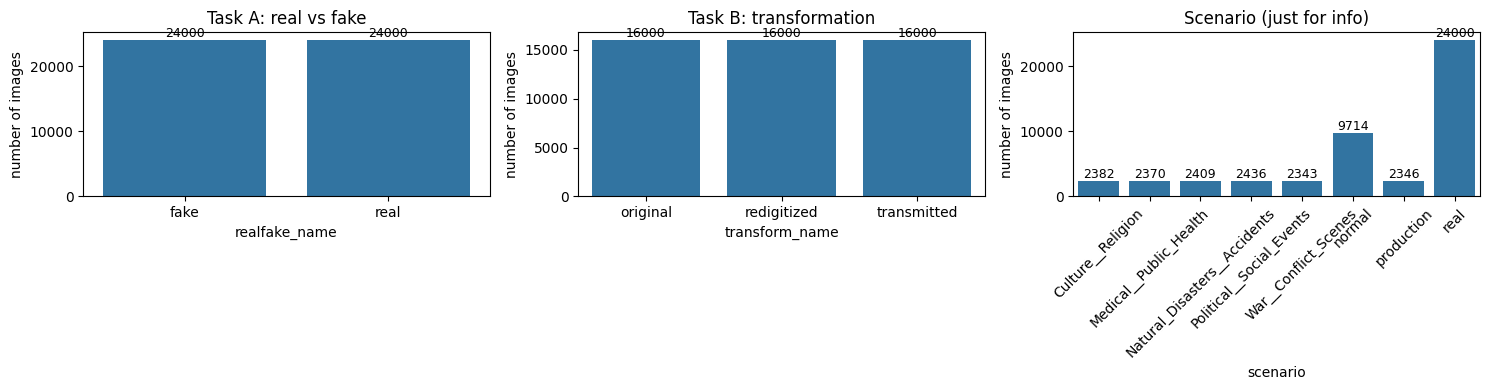

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_counts(subset.realfake_name,  "Task A: real vs fake",       axes[0])
bar_counts(subset.transform_name, "Task B: transformation",     axes[1])
bar_counts(subset.scenario,       "Scenario (just for info)",   axes[2])
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 5. Split into train, validation and test by scene [data]
We split the scenes, not the images, so all three versions of a scene stay together. First we
peel off the training scenes, then we cut the rest in half into validation and test. Stratifying
keeps the real/fake ratio steady in every split.

In [28]:
if REBUILD:
    # One row per scene again, so we split scenes (not images): all 3 copies stay together.
    scenes = subset.drop_duplicates("base_id")[["base_id", "realfake"]]
    train_ratio, val_ratio, test_ratio = SPLIT_RATIOS

    # Step 1: take out the training scenes. "temp" holds validation + test for now.
    train_scenes, temp_scenes = train_test_split(
        scenes,
        test_size=val_ratio + test_ratio,          # e.g. 0.30 -> goes to val + test
        stratify=scenes["realfake"],               # keep real/fake balanced
        random_state=SEED,
    )

    # Step 2: cut "temp" in half into validation and test.
    val_scenes, test_scenes = train_test_split(
        temp_scenes,
        test_size=test_ratio / (val_ratio + test_ratio),   # half of temp -> test
        stratify=temp_scenes["realfake"],
        random_state=SEED,
    )

    # Give every image the split that its scene landed in.
    val_ids  = set(val_scenes["base_id"])
    test_ids = set(test_scenes["base_id"])
    subset["split"] = "train"                                  # everyone starts as train
    subset.loc[subset["base_id"].isin(val_ids),  "split"] = "val"
    subset.loc[subset["base_id"].isin(test_ids), "split"] = "test"

    print(subset["split"].value_counts(), "\n")
    print("Real/fake share inside each split (should stay about 50/50):")
    print(pd.crosstab(subset["split"], subset["realfake_name"], normalize="index").round(3))

split
train    33600
test      7200
val       7200
Name: count, dtype: int64 

Real/fake share inside each split (should stay about 50/50):
realfake_name  fake  real
split                    
test            0.5   0.5
train           0.5   0.5
val             0.5   0.5


### 6. Prove there is no leakage [data]
The most important correctness check: a scene must live in exactly one split. If any scene
appears in two splits, one of these asserts stops the notebook. This runs on the loaded table too.

In [29]:
train_ids = set(subset[subset.split == "train"].base_id)
val_ids   = set(subset[subset.split == "val"].base_id)
test_ids  = set(subset[subset.split == "test"].base_id)

assert train_ids.isdisjoint(val_ids),  "Leak: a scene is in both train and val!"
assert train_ids.isdisjoint(test_ids), "Leak: a scene is in both train and test!"
assert val_ids.isdisjoint(test_ids),   "Leak: a scene is in both val and test!"

print("No leakage: every scene is in exactly one split.")
print(f"  train: {len(train_ids)} scenes | val: {len(val_ids)} | test: {len(test_ids)}")

No leakage: every scene is in exactly one split.
  train: 11200 scenes | val: 2400 | test: 2400


### 7. Save the table [data]
Later sections and reruns just load this CSV instead of scanning the folders again.

In [30]:
if REBUILD:
    subset.to_csv(INDEX_CSV, index=False)
    print("Saved the image table to:", INDEX_CSV.resolve())
subset.head()

Saved the image table to: /kaggle/working/rrdataset_index.csv


,path,realfake,realfake_name,transform,transform_name,base_id,scenario,split
0,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_002233,real,train
1,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_000837,real,test
2,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_005864,real,test
3,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_009458,real,val
4,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_004735,real,test


## Network
The models. A frozen DINOv3 backbone turns each image into 768 numbers, then small heads turn
those numbers into answers. We also define the joint model and the LoRA model here.

### Log in to HuggingFace [DINOv3]
DINOv3 is a gated model, so we need a token to download it. On Kaggle the token is a Secret, on
a local machine it is the HF_TOKEN global or environment variable.

In [31]:
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")   # Kaggle
except Exception:
    hf_token = HF_TOKEN or os.environ.get("HF_TOKEN")       # local: global above, or env var

if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("No HF_TOKEN found.")

Logged in to HuggingFace.


### Load the frozen backbone [DINOv3]
We do not train the backbone, so we lock its weights and put it in eval mode. It is used only as
a fixed image to numbers converter.

In [32]:
processor = AutoImageProcessor.from_pretrained(BACKBONE_ID)
backbone = AutoModel.from_pretrained(BACKBONE_ID).to(device).eval()
for p in backbone.parameters():
    p.requires_grad = False
print("Loaded backbone:", BACKBONE_ID)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loaded backbone: facebook/dinov3-vitb16-pretrain-lvd1689m


### Extract and cache the features [DINOv3]
Because the backbone is frozen, an image always gives the same vector. We compute every vector
once, save them to feats.npy, and reuse them, so head training takes seconds instead of hours.

In [33]:
if FEATS_NPY.exists():
    feats = np.load(FEATS_NPY)
    print("Loaded cached features:", feats.shape)
else:
    feats = extract_features(subset["path"].tolist())
    np.save(FEATS_NPY, feats)
    print("\nSaved features:", feats.shape)

assert feats.shape[0] == len(subset)
assert feats.shape[1] == FEATURE_DIM

  48000 / 48000 images
Saved features: (48000, 768)


### The single-task head [baseline]
A small MLP: 768 -> 256 -> GELU -> Dropout -> classes. We use the same class for both baselines,
only the number of output classes changes (2 for real/fake, 3 for the transformation).

In [34]:
class MLPHead(nn.Module):
    def __init__(self, n_classes, in_dim=FEATURE_DIM, hidden=HIDDEN_DIM, p_drop=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)

### The joint model [joint model]
One model for both tasks: a shared trunk (768 -> hidden -> GELU -> Dropout) that both tasks
train, then one head each. The shared trunk is where the two tasks can help or hurt each other.

In [35]:
class JointModel(nn.Module):
    def __init__(self, in_dim=FEATURE_DIM, hidden=HIDDEN_DIM, p_drop=DROPOUT):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
        )
        self.head_a = nn.Linear(hidden, 2)   # real vs fake
        self.head_b = nn.Linear(hidden, 3)   # transformation

    def forward(self, x):
        z = self.trunk(x)
        return self.head_a(z), self.head_b(z)

### The LoRA model [LoRA]
Same shared-trunk plus two-heads idea, but now the backbone is not frozen: LoRA adds tiny
trainable adapters inside it, so the backbone can keep a bit of the degradation detail it would
normally throw away. It works on images, not cached features, and trains only adapters plus
trunk plus heads (the original backbone weights stay fixed).

In [36]:
class LoRAJointModel(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, p_drop=DROPOUT):
        super().__init__()
        base = AutoModel.from_pretrained(BACKBONE_ID)
        lora_cfg = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.05,
                              target_modules="all-linear", bias="none")
        self.backbone = get_peft_model(base, lora_cfg)   # base frozen, adapters trainable
        self.trunk = nn.Sequential(
            nn.Linear(FEATURE_DIM, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
        )
        self.head_a = nn.Linear(hidden, 2)
        self.head_b = nn.Linear(hidden, 3)

    def forward(self, pixel_values):
        cls = self.backbone(pixel_values=pixel_values).last_hidden_state[:, 0]
        z = self.trunk(cls)
        return self.head_a(z), self.head_b(z)

## Train
Train the two single-task baselines on the cached features, then the joint model (with the
loss-weight and bottleneck sweep), a small hyperparameter search, and finally the LoRA model.

### Put features and labels into tensors [setup]
Turn the cached features and the two label columns into tensors, and mark which rows are train,
validation and test, so every training function can index them quickly.

In [37]:
features_tensor  = torch.tensor(feats, dtype=torch.float32)
labels_realfake  = torch.tensor(subset["realfake"].values,  dtype=torch.long)
labels_transform = torch.tensor(subset["transform"].values, dtype=torch.long)
split_column = subset["split"].values

is_train = torch.tensor(split_column == "train")
is_val   = torch.tensor(split_column == "val")
is_test  = torch.tensor(split_column == "test")
print("train / val / test:", int(is_train.sum()), int(is_val.sum()), int(is_test.sum()))

train / val / test: 33600 7200 7200


### The single-task training loop [baseline]
One loop reused for both baselines. AdamW plus cross-entropy, keeping the weights with the best
validation accuracy, and stopping early if validation stops improving.

In [38]:
def train_head(n_classes, y_all, hidden=HIDDEN_DIM, p_drop=DROPOUT, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    set_seed(SEED)   # deterministic weight init for every call
    head = MLPHead(n_classes=n_classes, hidden=hidden, p_drop=p_drop).to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr,  ytr  = features_tensor[is_train], y_all[is_train]
    Xval, yval = features_tensor[is_val],   y_all[is_val]
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))   # deterministic shuffling

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state, no_improve = 0.0, None, 0
    for epoch in range(epochs):
        head.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(head(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        history["train_loss"].append(epoch_loss / len(Xtr))
        history["train_acc"].append(accuracy(head, Xtr, ytr))
        val_acc = accuracy(head, Xval, yval)
        history["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state, no_improve = val_acc, copy.deepcopy(head.state_dict()), 0
        else:
            no_improve += 1
        print(f"  epoch {epoch + 1:2d}/{epochs} | val acc {val_acc:.3f}", end="\r")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch + 1} (no val improvement for {PATIENCE} epochs).")
            break

    head.load_state_dict(best_state)
    print(f"\nBest validation accuracy: {best_acc:.3f}")
    return head, history

### Baseline A: real vs fake [baseline]
Train one head to do only the real/fake task, as a reference number for the joint model.

In [39]:
print("Training Task A (real vs fake)...")
head_realfake, history_realfake = train_head(n_classes=2, y_all=labels_realfake)

Training Task A (real vs fake)...
  epoch 16/50 | val acc 0.945
Early stopping at epoch 16 (no val improvement for 8 epochs).

Best validation accuracy: 0.947


### Baseline B: transformation [baseline]
Train one head to do only the 3-class transformation task, the second reference number.

In [40]:
print("Training Task B (transformation)...")
head_transform, history_transform = train_head(n_classes=3, y_all=labels_transform)

Training Task B (transformation)...
  epoch 19/50 | val acc 0.882
Early stopping at epoch 19 (no val improvement for 8 epochs).

Best validation accuracy: 0.884


### Training curves of the baselines [baseline]
Plot loss and accuracy per epoch for both baselines, to check they learned and did not overfit.

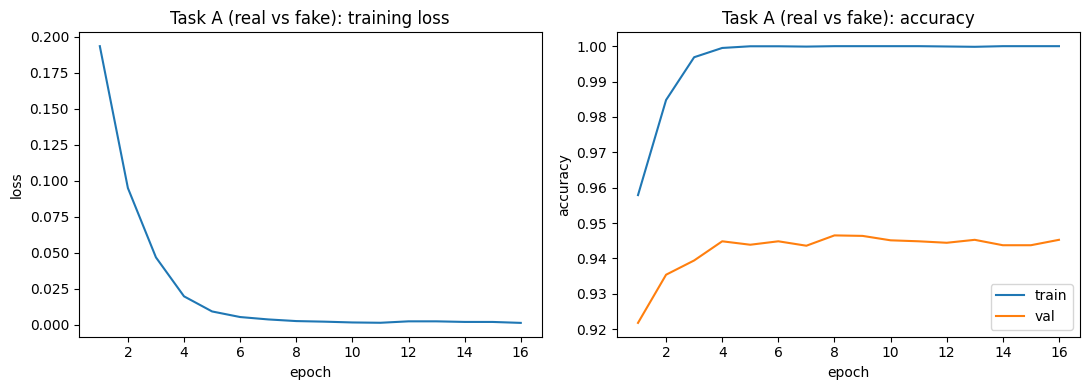

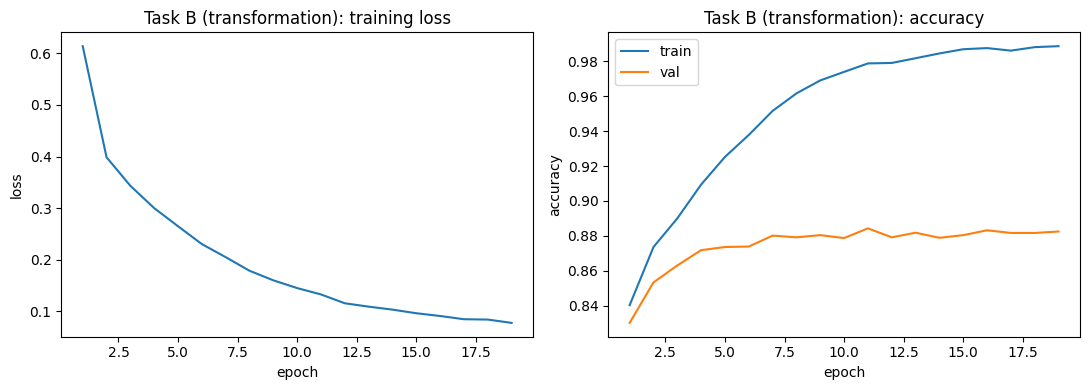

In [41]:
plot_curves(history_realfake,  "Task A (real vs fake)")
plot_curves(history_transform, "Task B (transformation)")

### The joint training loop [joint model]
Trains the joint model on the combined loss w_A * loss_A + w_B * loss_B, keeping the weights with
the best average validation accuracy. We re-seed at the start so every run begins the same way.

In [42]:
def train_joint(w_a, w_b, hidden=HIDDEN_DIM, p_drop=DROPOUT, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    set_seed(SEED)   # same start for every run, so only the weights differ
    model = JointModel(hidden=hidden, p_drop=p_drop).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr = features_tensor[is_train]
    ya_tr, yb_tr = labels_realfake[is_train], labels_transform[is_train]
    loader = DataLoader(TensorDataset(Xtr, ya_tr, yb_tr), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))   # deterministic shuffling

    best_score, best_state, no_improve = 0.0, None, 0
    for epoch in range(epochs):
        model.train()
        for xb, ya, yb in loader:
            xb, ya, yb = xb.to(device), ya.to(device), yb.to(device)
            optimizer.zero_grad()
            out_a, out_b = model(xb)
            loss = w_a * loss_fn(out_a, ya) + w_b * loss_fn(out_b, yb)
            loss.backward()
            optimizer.step()
        acc_a, acc_b = joint_accuracy(model, is_val)
        score = (acc_a + acc_b) / 2
        if score > best_score:
            best_score, best_state, no_improve = score, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
        print(f"  epoch {epoch + 1:2d}/{epochs} | val A {acc_a:.3f} | val B {acc_b:.3f}", end="\r")
        if no_improve >= PATIENCE:
            break

    model.load_state_dict(best_state)
    print()
    return model

### Hyperparameter grid search [joint model + tuning]
We use sklearn's ParameterGrid to try a few settings and read off which each network prefers
(chosen on validation accuracy). The joint model's best setting is then reused for the sweep.

In [43]:
param_grid = {"lr": [1e-3, 3e-4], "hidden": [128, 256], "dropout": [0.1, 0.3]}

def grid_search_head(n_classes, y_all):
    rows = []
    for p in ParameterGrid(param_grid):
        _, hist = train_head(n_classes=n_classes, y_all=y_all,
                             hidden=p["hidden"], p_drop=p["dropout"], lr=p["lr"])
        rows.append({**p, "val_acc": max(hist["val_acc"])})
    return pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)

def grid_search_joint():
    rows = []
    for p in ParameterGrid(param_grid):
        model = train_joint(w_a=1.0, w_b=1.0, hidden=p["hidden"], p_drop=p["dropout"], lr=p["lr"])
        acc_a, acc_b = joint_accuracy(model, is_val)
        rows.append({**p, "val_acc": (acc_a + acc_b) / 2})
    return pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)

grid_taskA = grid_search_head(2, labels_realfake)
grid_taskB = grid_search_head(3, labels_transform)
grid_joint = grid_search_joint()

for name, g in [("taskA", grid_taskA), ("taskB", grid_taskB), ("joint", grid_joint)]:
    g.to_csv(OUT_DIR / f"grid_{name}.csv", index=False)
    print(f"Best for {name}: {g.iloc[0].to_dict()}")

# the joint model's best settings, reused by the sweep below
best_joint   = grid_joint.iloc[0]
best_lr      = float(best_joint["lr"])
best_dropout = float(best_joint["dropout"])
best_hidden  = int(best_joint["hidden"])
print(f"\nUsing for the sweep: lr={best_lr}, hidden={best_hidden}, dropout={best_dropout}")

display(grid_taskA, grid_taskB, grid_joint)

  epoch 25/50 | val acc 0.943
Early stopping at epoch 25 (no val improvement for 8 epochs).

Best validation accuracy: 0.944
  epoch 33/50 | val acc 0.943
Early stopping at epoch 33 (no val improvement for 8 epochs).

Best validation accuracy: 0.944
  epoch 26/50 | val acc 0.948
Early stopping at epoch 26 (no val improvement for 8 epochs).

Best validation accuracy: 0.948
  epoch 48/50 | val acc 0.947
Early stopping at epoch 48 (no val improvement for 8 epochs).

Best validation accuracy: 0.947
  epoch 24/50 | val acc 0.941
Early stopping at epoch 24 (no val improvement for 8 epochs).

Best validation accuracy: 0.945
  epoch 28/50 | val acc 0.942
Early stopping at epoch 28 (no val improvement for 8 epochs).

Best validation accuracy: 0.944
  epoch 16/50 | val acc 0.945
Early stopping at epoch 16 (no val improvement for 8 epochs).

Best validation accuracy: 0.947
  epoch 32/50 | val acc 0.947
Early stopping at epoch 32 (no val improvement for 8 epochs).

Best validation accuracy: 0.948


,dropout,hidden,lr,val_acc
0,0.1,256,0.0010,0.948194
1,0.3,256,0.0003,0.948056
2,0.1,256,0.0003,0.946806
3,0.3,256,0.0010,0.946528
4,0.3,128,0.0010,0.945417
5,0.3,128,0.0003,0.944444
6,0.1,128,0.0010,0.944306
7,0.1,128,0.0003,0.944167


,dropout,hidden,lr,val_acc
0,0.1,128,0.0003,0.889444
1,0.3,128,0.0003,0.888194
2,0.3,256,0.0003,0.887361
3,0.1,256,0.0003,0.887222
4,0.3,128,0.0010,0.884722
5,0.1,256,0.0010,0.884306
6,0.3,256,0.0010,0.884306
7,0.1,128,0.0010,0.883472


,dropout,hidden,lr,val_acc
0,0.3,256,0.0003,0.917708
1,0.3,256,0.0010,0.916042
2,0.1,256,0.0003,0.915625
3,0.1,256,0.0010,0.914097
4,0.3,128,0.0003,0.913333
5,0.3,128,0.0010,0.913333
6,0.1,128,0.0003,0.912431
7,0.1,128,0.0010,0.911250


### Loss-weight and bottleneck sweep [ablation]
Using the joint model's best settings from the grid search, we sweep w_B (with w_A = 1) for
several trunk sizes. The best trunk size is the main model; 1, 2, 4, 8 are bottlenecks that force
the tasks to share. Every model here is scored on validation only (the test set stays untouched
until the final evaluation). We keep the single best-on-validation model to start LoRA from, and
pull the main-trunk rows out as `sweep`.

In [44]:
hidden_sizes = sorted(set([1, 2, 4, 8, best_hidden]))   # small trunks + the best (main) trunk
ratios = [0, 0.25, 0.5, 1, 2, 4]                         # this is w_B (with w_A fixed to 1)

rows = []
joint_model, best_val = None, -1.0
for hidden in hidden_sizes:
    for w_b in ratios:
        model = train_joint(w_a=1.0, w_b=w_b, hidden=hidden, p_drop=best_dropout, lr=best_lr)
        acc_a, acc_b = joint_accuracy(model, is_val)      # validation only
        rows.append({"hidden": hidden, "w_A": 1.0, "w_B": w_b, "lr": best_lr,
                     "dropout": best_dropout, "seed": SEED,
                     "taskA_val": acc_a, "taskB_val": acc_b})
        print(f"hidden={hidden:3d} w_B={w_b}: val A {acc_a:.3f} | val B {acc_b:.3f}")
        score = (acc_a + acc_b) / 2
        if score > best_val:
            best_val, joint_model = score, model

bottleneck = pd.DataFrame(rows)
bottleneck.to_csv(OUT_DIR / "bottleneck_ablation.csv", index=False)

# the best trunk (main joint model) rows, used for the loss-weight plots
sweep = bottleneck[bottleneck["hidden"] == best_hidden].reset_index(drop=True)
sweep.to_csv(OUT_DIR / "loss_weight_sweep.csv", index=False)
print(f"\nBest joint model from the sweep: hidden={joint_model.trunk[0].out_features}, val score={best_val:.3f}")
sweep

  epoch  9/50 | val A 0.500 | val B 0.339
hidden=  1 w_B=0: val A 0.500 | val B 0.343
  epoch 46/50 | val A 0.917 | val B 0.349
hidden=  1 w_B=0.25: val A 0.917 | val B 0.350
  epoch 46/50 | val A 0.918 | val B 0.350
hidden=  1 w_B=0.5: val A 0.918 | val B 0.351
  epoch 39/50 | val A 0.918 | val B 0.355
hidden=  1 w_B=1: val A 0.916 | val B 0.359
  epoch 22/50 | val A 0.502 | val B 0.603
hidden=  1 w_B=2: val A 0.611 | val B 0.559
  epoch 50/50 | val A 0.506 | val B 0.667
hidden=  1 w_B=4: val A 0.509 | val B 0.666
  epoch 30/50 | val A 0.918 | val B 0.333
hidden=  2 w_B=0: val A 0.920 | val B 0.336
  epoch 16/50 | val A 0.920 | val B 0.364
hidden=  2 w_B=0.25: val A 0.912 | val B 0.378
  epoch 50/50 | val A 0.913 | val B 0.684
hidden=  2 w_B=0.5: val A 0.915 | val B 0.689
  epoch 50/50 | val A 0.917 | val B 0.741
hidden=  2 w_B=1: val A 0.918 | val B 0.746
  epoch 49/50 | val A 0.915 | val B 0.742
hidden=  2 w_B=2: val A 0.916 | val B 0.746
  epoch 16/50 | val A 0.557 | val B 0.826
hi

,hidden,w_A,w_B,lr,dropout,seed,taskA_val,taskB_val
0,256,1.0,0.00,0.0003,0.3,42,0.948056,0.313750
1,256,1.0,0.25,0.0003,0.3,42,0.946944,0.887083
2,256,1.0,0.50,0.0003,0.3,42,0.945000,0.887361
3,256,1.0,1.00,0.0003,0.3,42,0.945556,0.889861
4,256,1.0,2.00,0.0003,0.3,42,0.945000,0.890972
5,256,1.0,4.00,0.0003,0.3,42,0.942778,0.890000


### Train the LoRA model [LoRA]
This trains through the backbone on the images, so it is the slow part. We use mixed precision
for speed, balanced weights (w_A = w_B = 1), and we start the trunk and heads from the trained
joint model so LoRA only has to adapt the backbone. The result is cached so reruns skip training.

In [45]:
def train_lora(w_a=1.0, w_b=1.0, init_from=None, epochs=LORA_EPOCHS, lr=LORA_LR, batch_size=LORA_BATCH):
    set_seed(SEED)
    if init_from is not None:
        # Warm start: build the LoRA model with the same trunk size as the joint model, then copy
        # its trunk + heads, so LoRA only has to adapt the backbone.
        model = LoRAJointModel(hidden=init_from.trunk[0].out_features).to(device)
        model.trunk.load_state_dict(init_from.trunk.state_dict())
        model.head_a.load_state_dict(init_from.head_a.state_dict())
        model.head_b.load_state_dict(init_from.head_b.state_dict())
    else:
        model = LoRAJointModel().to(device)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    use_amp = (device.type == "cuda")          # mixed precision: run the backbone in fp16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    train_frame = subset[subset["split"] == "train"]
    loader = DataLoader(LabeledImageDataset(train_frame), batch_size=batch_size, shuffle=True,
                        num_workers=4, pin_memory=True, persistent_workers=True,
                        generator=torch.Generator().manual_seed(SEED))   # deterministic shuffling

    for epoch in range(epochs):
        model.train()
        for px, ya, yb in loader:
            px, ya, yb = px.to(device, non_blocking=True), ya.to(device), yb.to(device)
            optimizer.zero_grad()
            with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
                out_a, out_b = model(px)
                loss = w_a * loss_fn(out_a, ya) + w_b * loss_fn(out_b, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        print(f"  epoch {epoch + 1}/{epochs} done")
    return model

joint_hidden = joint_model.trunk[0].out_features   # match the LoRA trunk to the best joint model

if RETRAIN_LORA and LORA_WEIGHTS.exists():
    LORA_WEIGHTS.unlink()
    print("Removed stale LoRA cache:", LORA_WEIGHTS)
else:
    print("No LoRA cache to remove (or RETRAIN_LORA=False).")

if LORA_WEIGHTS.exists():
    lora_model = LoRAJointModel(hidden=joint_hidden).to(device)
    lora_model.load_state_dict(torch.load(LORA_WEIGHTS, map_location=device), strict=False)
    print("Loaded saved LoRA weights, skipping training.")
else:
    print("Training LoRA model (this trains through the backbone, so it is slow)...")
    lora_model = train_lora(init_from=joint_model)   # start from the best joint trunk + heads
    # save only the trainable params (adapters + trunk + heads) so the file stays small
    trainable = {n: p.detach().cpu() for n, p in lora_model.named_parameters() if p.requires_grad}
    torch.save(trainable, LORA_WEIGHTS)
    print("Saved LoRA weights to:", LORA_WEIGHTS)

No LoRA cache to remove (or RETRAIN_LORA=False).
Training LoRA model (this trains through the backbone, so it is slow)...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch 1/3 done
  epoch 2/3 done
  epoch 3/3 done
Saved LoRA weights to: /kaggle/working/lora_model.pt


## Evaluation
Score every model on the test split. For real/fake we report accuracy, real- and fake-accuracy
and AUC; for the transformation we report accuracy. Every model also gets confusion matrices,
and we finish with the per-transformation breakdown that answers the project's main question.

### Task A: real vs fake [baseline]
Score the real/fake baseline on the test set: overall, per-class accuracy, AUC, and its matrix.

Task A - real vs fake
  accuracy      : 0.942
  real accuracy : 0.933
  fake accuracy : 0.952
  AUC           : 0.987


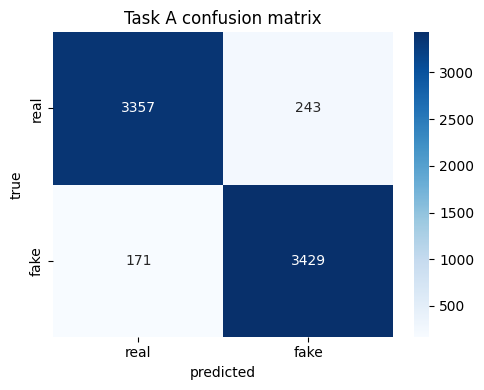

Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.952,0.932,0.942,3600.000
fake,0.934,0.952,0.943,3600.000
accuracy,0.942,0.942,0.942,0.942
macro avg,0.943,0.942,0.942,7200.000
weighted avg,0.943,0.942,0.942,7200.000


In [46]:
y_true_A = labels_realfake[is_test]
with torch.no_grad():
    logits_A = head_realfake(features_tensor[is_test].to(device)).cpu()
y_pred_A   = logits_A.argmax(1)
proba_fake = logits_A.softmax(1)[:, 1].numpy()

print("Task A - real vs fake")
print(f"  accuracy      : {(y_pred_A == y_true_A).float().mean().item():.3f}")
print(f"  real accuracy : {class_accuracy(y_true_A, y_pred_A, 0):.3f}")
print(f"  fake accuracy : {class_accuracy(y_true_A, y_pred_A, 1):.3f}")
print(f"  AUC           : {roc_auc_score(y_true_A.numpy(), proba_fake):.3f}")

plot_confusion(y_true_A, y_pred_A, [REALFAKE_NAME[0], REALFAKE_NAME[1]], "Task A confusion matrix")
print("Task A precision / recall / F1:")
display(metrics_table(y_true_A, y_pred_A, [REALFAKE_NAME[0], REALFAKE_NAME[1]]))

### Task B: transformation [baseline]
Score the transformation baseline on the test set: accuracy and its 3-class confusion matrix.

Task B - transformation
  accuracy : 0.876


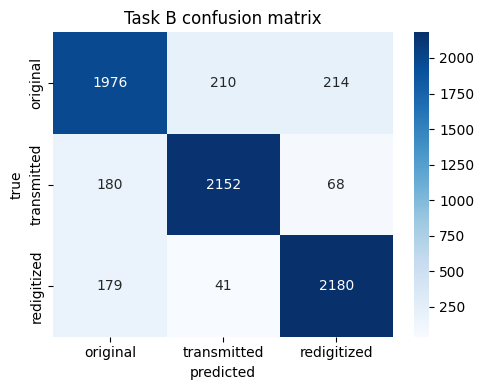

Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.846,0.823,0.835,2400.000
transmitted,0.896,0.897,0.896,2400.000
redigitized,0.885,0.908,0.897,2400.000
accuracy,0.876,0.876,0.876,0.876
macro avg,0.876,0.876,0.876,7200.000
weighted avg,0.876,0.876,0.876,7200.000


In [47]:
y_true_B = labels_transform[is_test]
with torch.no_grad():
    y_pred_B = head_transform(features_tensor[is_test].to(device)).argmax(1).cpu()

print("Task B - transformation")
print(f"  accuracy : {(y_pred_B == y_true_B).float().mean().item():.3f}")

names = [TRANSFORM_NAME[k] for k in ["original", "transfer", "redigital"]]
plot_confusion(y_true_B, y_pred_B, names, "Task B confusion matrix")
print("Task B precision / recall / F1:")
display(metrics_table(y_true_B, y_pred_B, names))

# keep the baseline test accuracies so we can compare them to the joint model later
baseline_taskA_acc = (y_pred_A == y_true_A).float().mean().item()
baseline_taskB_acc = (y_pred_B == y_true_B).float().mean().item()

### Compete or complement? [ablation]
Plot the loss-weight sweep (validation accuracy). If raising one task's accuracy lowers the
other's they compete; if both stay high together they complement.

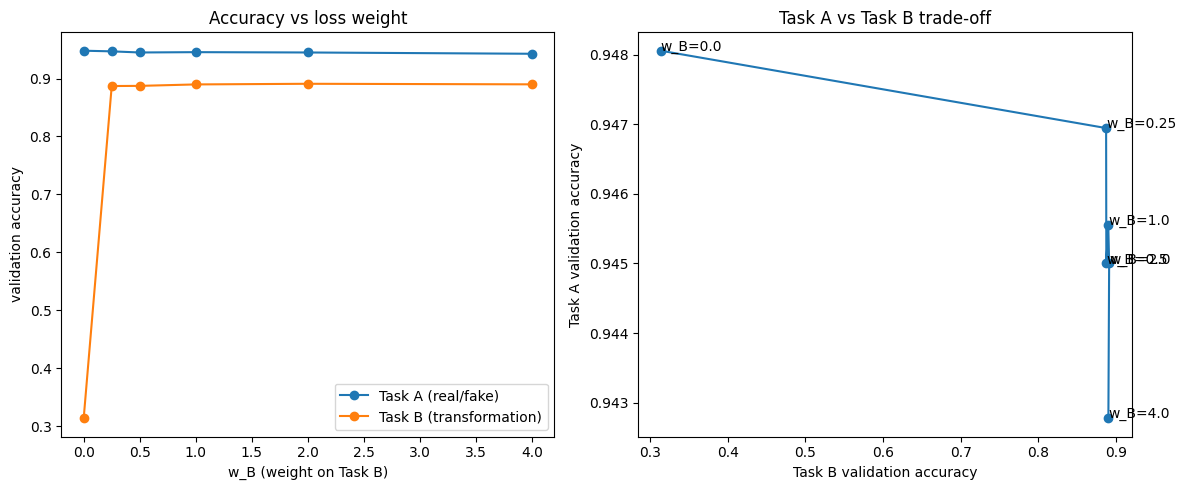

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: the two accuracies as w_B grows
axes[0].plot(sweep["w_B"], sweep["taskA_val"], "-o", label="Task A (real/fake)")
axes[0].plot(sweep["w_B"], sweep["taskB_val"], "-o", label="Task B (transformation)")
axes[0].set_xlabel("w_B (weight on Task B)")
axes[0].set_ylabel("validation accuracy")
axes[0].set_title("Accuracy vs loss weight")
axes[0].legend()

# right: the trade-off curve between the two tasks
axes[1].plot(sweep["taskB_val"], sweep["taskA_val"], "-o")
for _, row in sweep.iterrows():
    axes[1].annotate(f"w_B={row['w_B']}", (row["taskB_val"], row["taskA_val"]))
axes[1].set_xlabel("Task B validation accuracy")
axes[1].set_ylabel("Task A validation accuracy")
axes[1].set_title("Task A vs Task B trade-off")

plt.tight_layout()
plt.show()

### Baselines vs joint [joint model]
Compare the two separate baselines with the best joint model from the sweep.

In [49]:
joint_test_A, joint_test_B = joint_accuracy(joint_model, is_test)
compare = pd.DataFrame({
    "Task A acc": [baseline_taskA_acc, joint_test_A],
    "Task B acc": [baseline_taskB_acc, joint_test_B],
}, index=["baselines (separate)", "joint (best)"])
compare.round(3)

,Task A acc,Task B acc
baselines (separate),0.942,0.876
joint (best),0.940,0.881


### Confusion matrices of the joint model [joint model]
The best joint model on the test set, so its mistakes can be compared with the baselines.

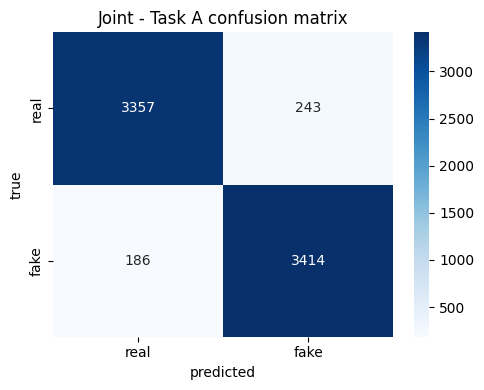

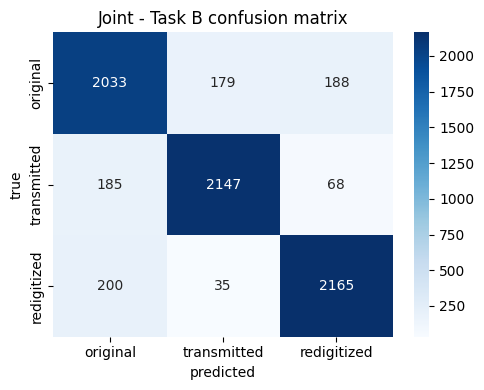

Joint - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.948,0.932,0.940,3600.00
fake,0.934,0.948,0.941,3600.00
accuracy,0.940,0.940,0.940,0.94
macro avg,0.941,0.940,0.940,7200.00
weighted avg,0.941,0.940,0.940,7200.00


Joint - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.841,0.847,0.844,2400.000
transmitted,0.909,0.895,0.902,2400.000
redigitized,0.894,0.902,0.898,2400.000
accuracy,0.881,0.881,0.881,0.881
macro avg,0.881,0.881,0.881,7200.000
weighted avg,0.881,0.881,0.881,7200.000


In [50]:
joint_pred_A, joint_pred_B = joint_predict(joint_model, is_test)
plot_confusion(labels_realfake[is_test],  joint_pred_A, [REALFAKE_NAME[0], REALFAKE_NAME[1]], "Joint - Task A confusion matrix")
plot_confusion(labels_transform[is_test], joint_pred_B, names, "Joint - Task B confusion matrix")
print("Joint - Task A precision / recall / F1:")
display(metrics_table(labels_realfake[is_test], joint_pred_A, [REALFAKE_NAME[0], REALFAKE_NAME[1]]))
print("Joint - Task B precision / recall / F1:")
display(metrics_table(labels_transform[is_test], joint_pred_B, names))

### Trade-off by trunk size [ablation]
One line per trunk size, traced as w_B grows. A flat high line means the tasks coexist; a line
that bends down to the right (Task A drops as Task B rises) means a small trunk makes them compete.

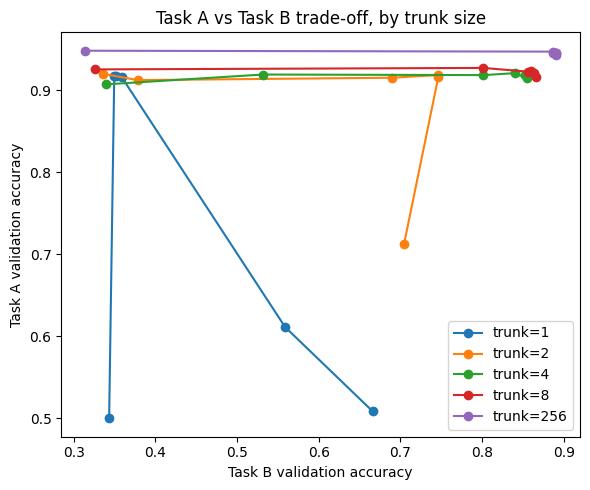

In [51]:
fig, ax = plt.subplots(figsize=(6, 5))
for hidden in hidden_sizes:
    sub = bottleneck[bottleneck["hidden"] == hidden].sort_values("w_B")
    ax.plot(sub["taskB_val"], sub["taskA_val"], "-o", label=f"trunk={hidden}")
ax.set_xlabel("Task B validation accuracy")
ax.set_ylabel("Task A validation accuracy")
ax.set_title("Task A vs Task B trade-off, by trunk size")
ax.legend()
plt.tight_layout()
plt.show()

### Frozen vs LoRA [LoRA]
Score the LoRA model on the test images and compare it to the joint model it started from (the
frozen backbone). Since both share the same trunk and heads, any gain is due to adapting the
backbone, and we expect it mostly on Task B.

In [52]:
test_frame = subset[subset["split"] == "test"]
pred_a, pred_b = predict_images(lora_model, test_frame)
true_a = torch.tensor(test_frame["realfake"].values)
true_b = torch.tensor(test_frame["transform"].values)
lora_taskA = (pred_a == true_a).float().mean().item()
lora_taskB = (pred_b == true_b).float().mean().item()

frozen_vs_lora = pd.DataFrame({
    "Task A acc": [joint_test_A, lora_taskA],
    "Task B acc": [joint_test_B, lora_taskB],
}, index=["frozen backbone (joint)", "LoRA backbone"])
frozen_vs_lora.round(3)

,Task A acc,Task B acc
frozen backbone (joint),0.940,0.881
LoRA backbone,0.947,0.946


### Confusion matrices of the LoRA model [LoRA]
The LoRA model on the test set, to compare its mistakes against the baselines and the joint model.

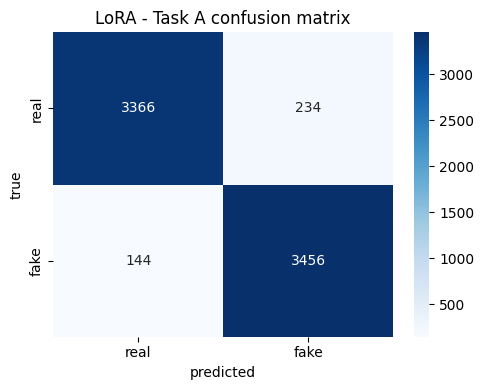

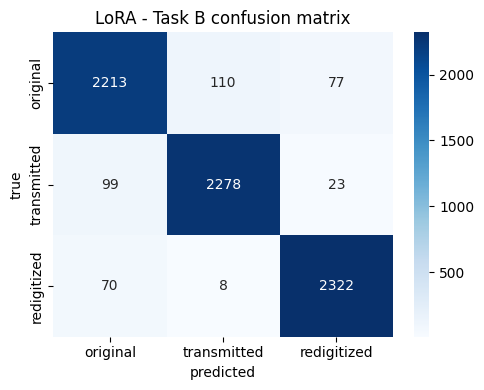

LoRA - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.959,0.935,0.947,3600.000
fake,0.937,0.960,0.948,3600.000
accuracy,0.948,0.948,0.948,0.948
macro avg,0.948,0.948,0.947,7200.000
weighted avg,0.948,0.948,0.947,7200.000


LoRA - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.929,0.922,0.926,2400.000
transmitted,0.951,0.949,0.950,2400.000
redigitized,0.959,0.968,0.963,2400.000
accuracy,0.946,0.946,0.946,0.946
macro avg,0.946,0.946,0.946,7200.000
weighted avg,0.946,0.946,0.946,7200.000


In [53]:
plot_confusion(true_a, pred_a, [REALFAKE_NAME[0], REALFAKE_NAME[1]], "LoRA - Task A confusion matrix")
plot_confusion(true_b, pred_b, names, "LoRA - Task B confusion matrix")
print("LoRA - Task A precision / recall / F1:")
display(metrics_table(true_a, pred_a, [REALFAKE_NAME[0], REALFAKE_NAME[1]]))
print("LoRA - Task B precision / recall / F1:")
display(metrics_table(true_b, pred_b, names))

### Real and fake accuracy per transformation [Objective 3]
The core analytical question: does real/fake detection degrade differently for real vs AI images
under each post-processing? We split the test real/fake accuracy by transformation, separately
for real and fake, for each detector. Re-digitized stays one class, because the dataset does not
tell us which of the 4 re-digitization methods made each image.


baseline: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.939,0.935,0.923
fake,0.942,0.962,0.954


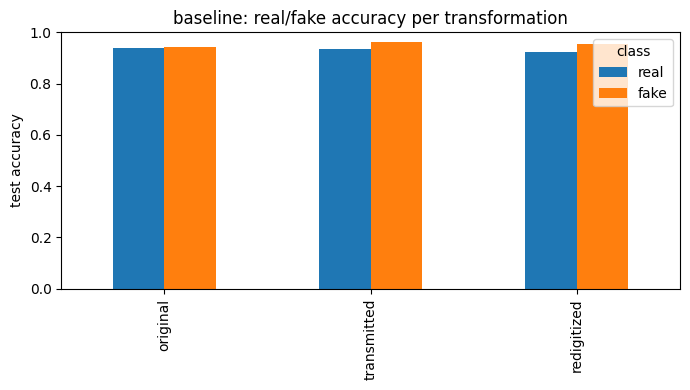


joint: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.936,0.938,0.923
fake,0.943,0.955,0.947


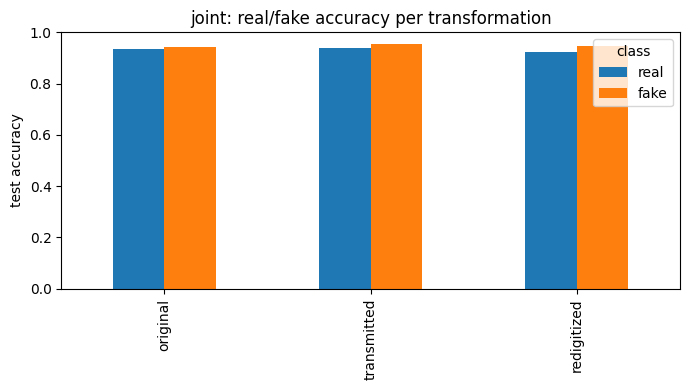


LoRA: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.937,0.945,0.923
fake,0.960,0.965,0.955


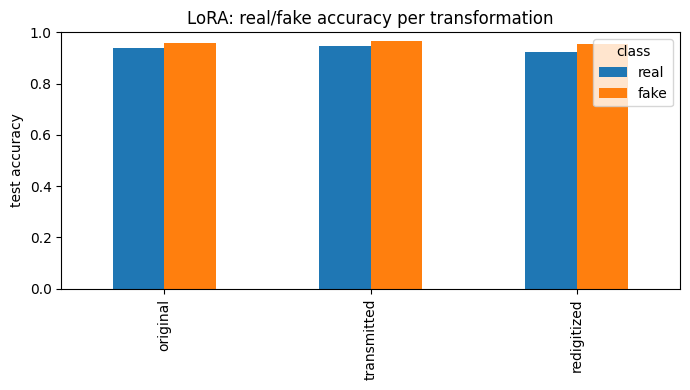

In [54]:
transform_test = labels_transform[is_test]
lora_transform_test = torch.tensor(test_frame["transform"].values)

breakdowns = {
    "baseline": per_transform_breakdown(y_true_A, y_pred_A, transform_test),
    "joint":    per_transform_breakdown(labels_realfake[is_test], joint_pred_A, transform_test),
    "LoRA":     per_transform_breakdown(true_a, pred_a, lora_transform_test),
}

for name_model, bd in breakdowns.items():
    print(f"\n{name_model}: real/fake accuracy per transformation")
    display(bd)
    bd.to_csv(OUT_DIR / f"breakdown_{name_model}.csv")
    plot_breakdown(bd, f"{name_model}: real/fake accuracy per transformation")

### All models per transformation [comparison]
A single figure comparing every model at once: real accuracy on the left, fake on the right,
one bar per model in each transformation, to see which model performs better where and how each
one holds up as the post-processing gets harsher.

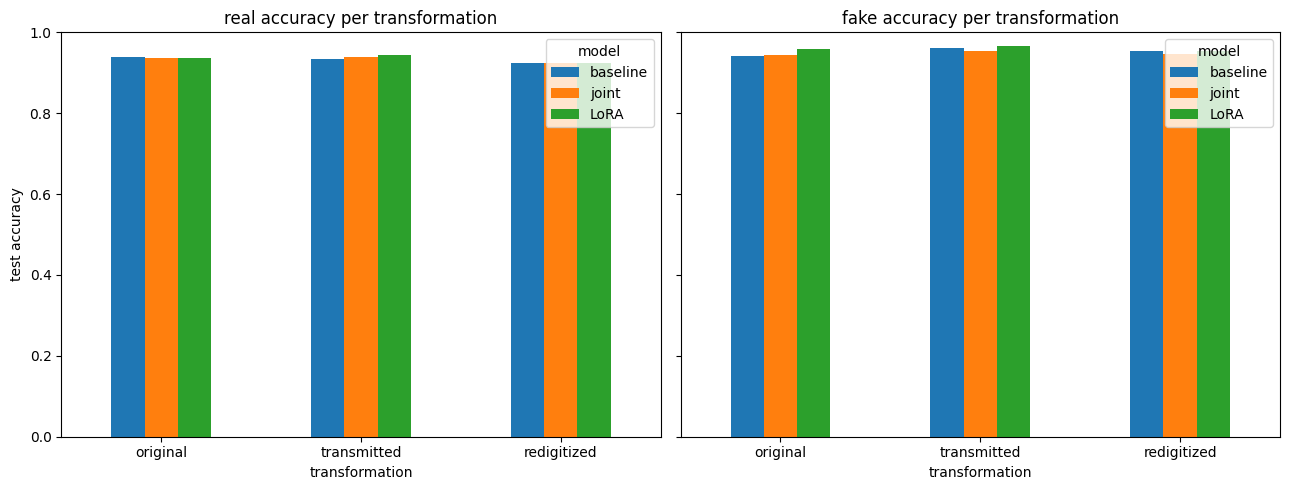

In [55]:
plot_breakdown_comparison(breakdowns)